# Extended Wigner's friend scenario (GHZ majority vote friend)

An adapted notebook from Will pertaining to the extended Wigner's friend scenario.

This notebook is intended to run a benchmark to show a local friendliness violation from an extended Wigner's Friend scenario running on a QPU. For our friends we will use a GHZ state of increasing size. First we run on a simulator, then a noisy simulator, then on a real QPU.

Relevant References:
- [1]: ["A strong no-go theorem on the Wigner's friend paradox"](https://arxiv.org/abs/1907.05607)

- [2]: ["A scalable tripartite Wigner's friend scenario"](https://arxiv.org/abs/2109.02298)

- [3]: ["Thought experiments in a quantum computer"](https://arxiv.org/abs/2209.06236)

## Imports

In [1]:
import numpy as np
import itertools
import random
from enum import Enum

import qiskit

from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.providers import Backend
from qiskit.providers import fake_provider
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

## Constants

In [2]:
def bitflip_model(p):
    # Example error probabilities
    p_meas = p
    p_gate1 = p

    # QuantumError objects
    error_meas = pauli_error([('X',p_meas), ('I', 1 - p_meas)])
    error_gate1 = pauli_error([('X',p_gate1), ('I', 1 - p_gate1)])
    error_gate2 = error_gate1.tensor(error_gate1)

    # Add errors to noise model
    noise_bit_flip = NoiseModel()
    noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
    noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
    noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_bit_flip

In [3]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3

# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [4]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
BETA = np.deg2rad(175)

## Expectation values

In [ ]:
def decode_results(results: dict[str, float], charlie_size: int, debbie_size: int) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")
   
                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]
            
    return decoded_results

In [5]:
def double_expect(settings: list[Setting], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return (
        probs.get("00", 0) 
        - probs.get("01", 0) 
        - probs.get("10", 0) 
        + probs.get("11", 0)
    )    

## Consider all experimental settings

In [6]:
def generate_all_experiments(
    backend: Backend,
    noise_model: NoiseModel,
    shots: float,
    angles: list[float],
    beta: float,
    charlie_size: int,
    debbie_size: int,
) -> dict[tuple[Observer, Observer], list[float]]:
    """Generate probabilitites for all combinations of experimental settings."""
    all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]
    
    results = {}
    for alice, bob in all_experiment_combos:
        ewfs_circuit = ewfs(alice, bob, angles, beta, charlie_size, debbie_size)

        job = qiskit.execute(
            experiments=ewfs_circuit,
            backend=backend,
            noise_model=noise_model,
            basis_gates=noise_model.basis_gates if noise_model is not None else None,
            shots=shots,
        )
        counts = job.result().get_counts()
        
        # Convert counts to probabilities.
        probabilities = {key[::-1]: value / shots for key, value in counts.items()}

        results[(alice, bob)] = probabilities
    return results

## State preparation

In [7]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

## CNOT ladder circuit

In [8]:
def cnot_ladder(qc: QuantumCircuit, observer: Observer, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)

## Circuit for extended Wigner's friend scenario

In [9]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)
    
def apply_setting(qc: QuantumCircuit, 
                  observer: Observer, 
                  setting: Setting, 
                  angle: float, 
                  observer_creg: list[int] | int, 
                  friend_qubits: int, 
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""    
    if setting is PEEK:
        # Ask friend for the outcome.
        qc.measure(friend_qubits, observer_creg)

    elif setting in [REVERSE_1, REVERSE_2]:
        cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)        

        if observer is BOB:
            qc.h(BOB)        
            qc.rz((BETA - ANGLES[1]), BOB)        
        ewfs_rotation(qc, observer, angle)            
        qc.measure(observer, observer_creg)
        
def ewfs(alice_setting: Setting, 
        bob_setting: Setting, 
        angles: list[float], 
        beta: float,
        charlie_size: int,
        debbie_size: int) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""    
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice", "Bob", "Charlie", "Debbie"])
    ]    
    if (alice_setting == PEEK and bob_setting != PEEK):
        measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
        alice_creg = list(range(charlie_size))
        bob_creg = charlie_size
    else:
        measurement = ClassicalRegister(meas_size, name="Measurement")
        alice_creg = 0
        bob_creg = 1
        
    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = range(sys_size, (sys_size + charlie_size))
    debbie_qubits = range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size))
    
    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)
    
    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
    cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    return qc

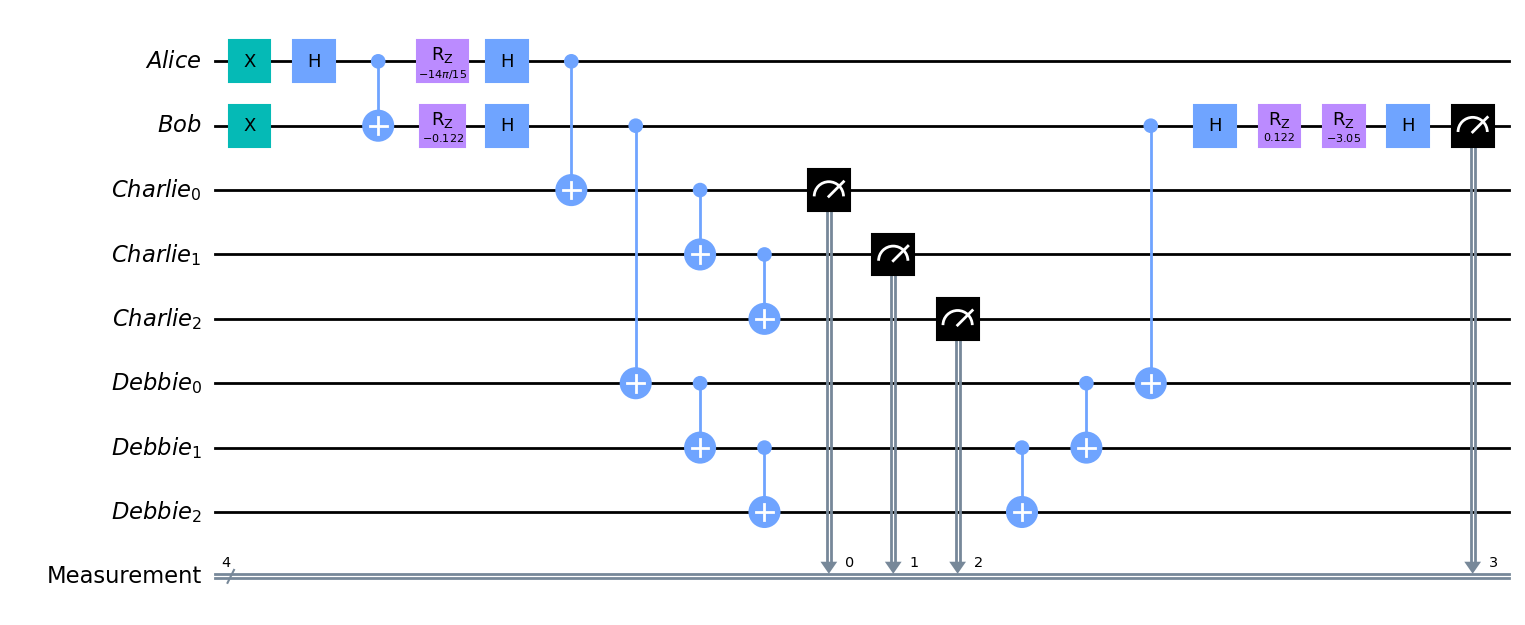

In [24]:
charlie_size = 3
debbie_size = 3
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], ANGLES, BETA, charlie_size, debbie_size)
qc.draw("mpl", style="clifford")

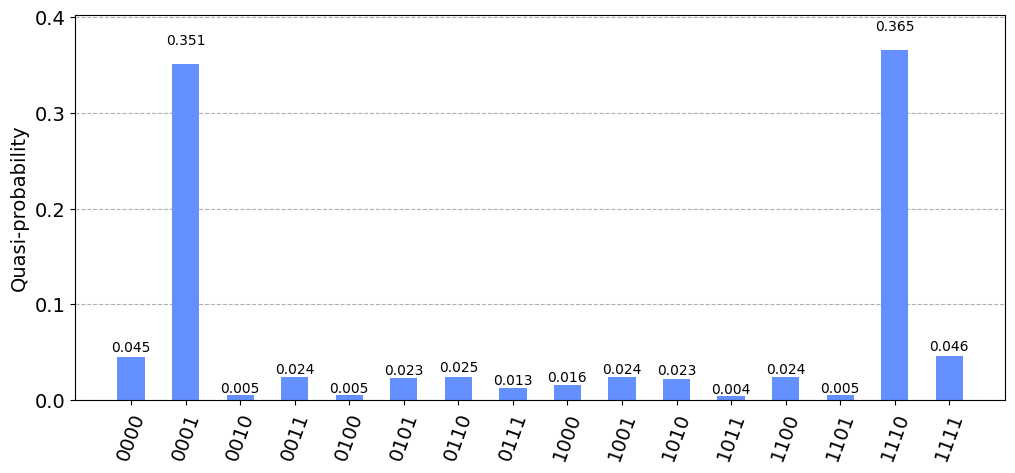

In [25]:
noise_bit_flip = bitflip_model(0.03)

job = qiskit.execute(
    experiments=qc,
    backend=qiskit.Aer.get_backend("aer_simulator"),
    noise_model=noise_bit_flip,
    basis_gates=noise_bit_flip.basis_gates if noise_bit_flip is not None else None,
    shots=1e4,
)
counts = job.result().get_counts()

# Convert counts to probabilities.
probabilities = {key[::-1]: value / 1e4 for key, value in counts.items()}

from qiskit.visualization import plot_distribution
plot_distribution(probabilities, figsize=(12, 5))

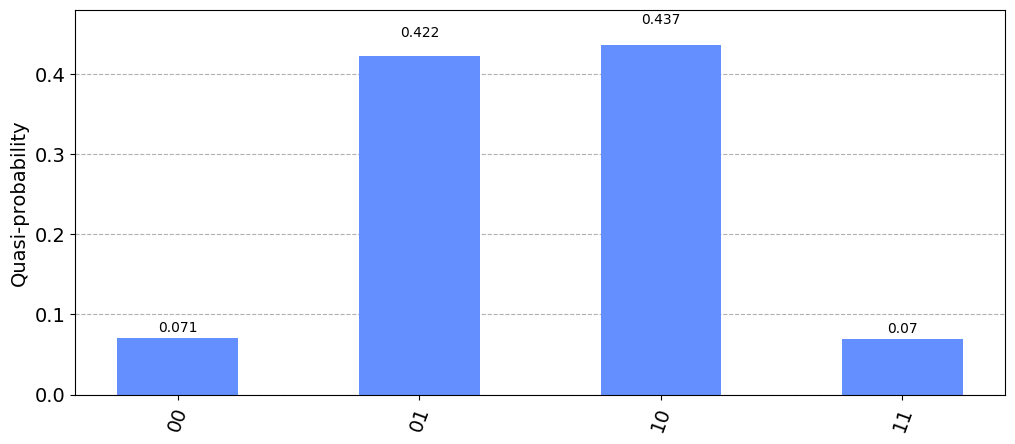

In [26]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size, debbie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

In [27]:
double_expect(setting, dec_res)

-0.7186

## Inequalities

In [28]:
def compute_inequalities(results, verbose=False):
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)
    
    # Eq. (18) from [1].
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2
    
    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")
        
    return {"semi_brukner": semi_brukner}

In [ ]:
def run_experiment(
    backend: Backend,
    noise_model: NoiseModel,
    friend_sizes: list[int],
    shots: float,
    num_trials: int = 1,
    verbose: bool = False,
):
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for friend_size in friend_sizes:
        for _ in range(num_trials):
            results = generate_all_experiments(
                backend=backend,
                noise_model=noise_model,
                shots=shots,
                angles=ANGLES,
                beta=BETA,
                charlie_size=friend_size,
                debbie_size=friend_size,
            )
            violations = compute_inequalities(decode_results(results, charlie_size=friend_size, debbie_size=friend_size), verbose=verbose)
            for key in violations:
                all_results[friend_size][key].append(violations[key])

    return all_results

In [ ]:
# Parameters for all plots
friend_sizes = range(1, 12)
num_trials = 1
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Ideal simulator data
noise_model = None
simulator_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
)